# Round 1 — Data Exploration

Loads raw `prices_round_1_day_*.csv` and `trades_round_1_day_*.csv` from `datasets/ROUND_1/`.

Products expected: `INTARIAN_PEPPER_ROOT`, `ASH_COATED_OSMIUM` (plus whatever else ships in round 1).

In [1]:
# --- Config ---
DATASET_DIR = "../datasets/ROUND_1/"
DAYS = [-2, -1, 0]  # which day files to load

In [2]:
import csv
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "monospace",
})

print("Ready.")

Ready.


## 1. Load Prices (order book snapshots)

In [3]:
def load_prices(dataset_dir, days):
    rows = []
    for d in days:
        path = Path(dataset_dir) / f"prices_round_1_day_{d}.csv"
        if not path.exists():
            print(f"Missing: {path}")
            continue
        with open(path) as f:
            for r in csv.DictReader(f, delimiter=";"):
                r["_day"] = d
                r["_global_ts"] = d * 1_000_000 + int(r["timestamp"])
                rows.append(r)
    return rows

prices = load_prices(DATASET_DIR, DAYS)
print(f"Loaded {len(prices)} price rows")
if prices:
    products = sorted(set(r["product"] for r in prices))
    print(f"Products: {products}")

Loaded 60000 price rows
Products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']


## 2. Mid Price Per Product (all days concatenated)

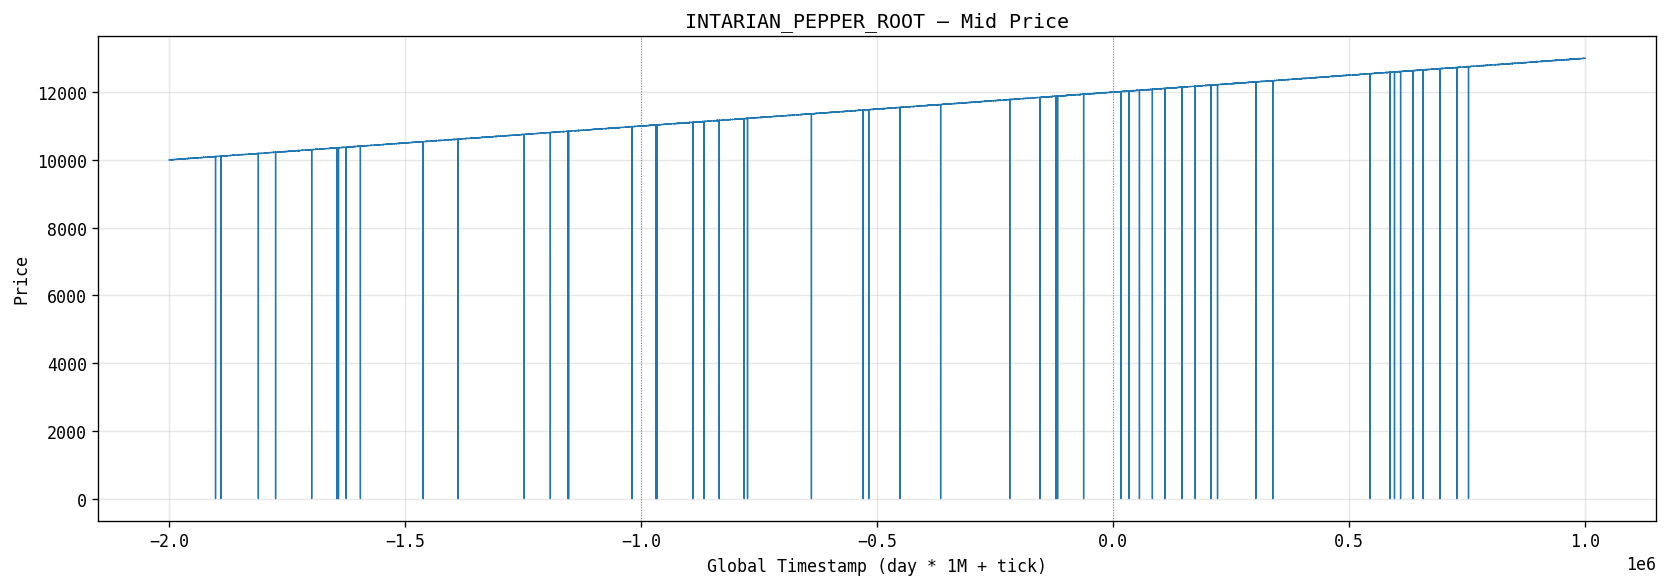

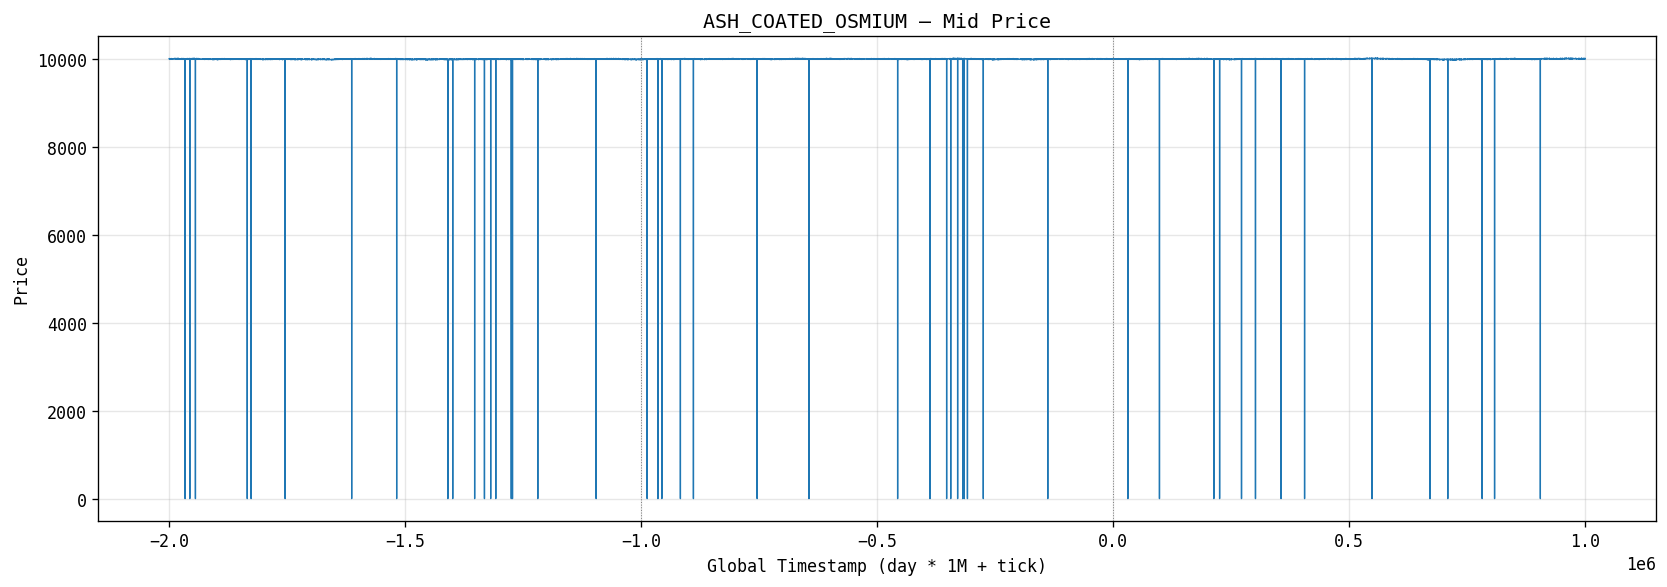

In [4]:
if prices:
    series = defaultdict(list)
    for r in prices:
        mid = r.get("mid_price")
        if mid:
            series[r["product"]].append((r["_global_ts"], float(mid)))

    for product, data in series.items():
        data.sort()
        fig, ax = plt.subplots()
        ax.plot([d[0] for d in data], [d[1] for d in data], linewidth=0.8)
        for d in DAYS[1:]:
            ax.axvline(d * 1_000_000, color="gray", linestyle=":", linewidth=0.6)
        ax.set_title(f"{product} — Mid Price")
        ax.set_xlabel("Global Timestamp (day * 1M + tick)")
        ax.set_ylabel("Price")
        plt.tight_layout()
        plt.show()

In [8]:
if prices:
    import statistics
    by_day = defaultdict(list)
    for r in prices:
        if r["product"] != "ASH_COATED_OSMIUM":
            continue
        try:
            mid = float(r.get("mid_price") or 0)
        except ValueError:
            continue
        if mid > 0:
            by_day[r["_day"]].append(mid)
    for d in sorted(by_day):
        v = by_day[d]
        print(f"Day {d}: mean={statistics.mean(v):.2f}  min={min(v):.1f}  max={max(v):.1f}  stdev={statistics.stdev(v):.2f}")


Day -2: mean=9998.17  min=9979.0  max=10019.0  stdev=5.22
Day -1: mean=10000.83  min=9982.0  max=10019.0  stdev=4.45
Day 0: mean=10001.61  min=9977.0  max=10023.0  stdev=5.68


## 3. Bid/Ask Spread

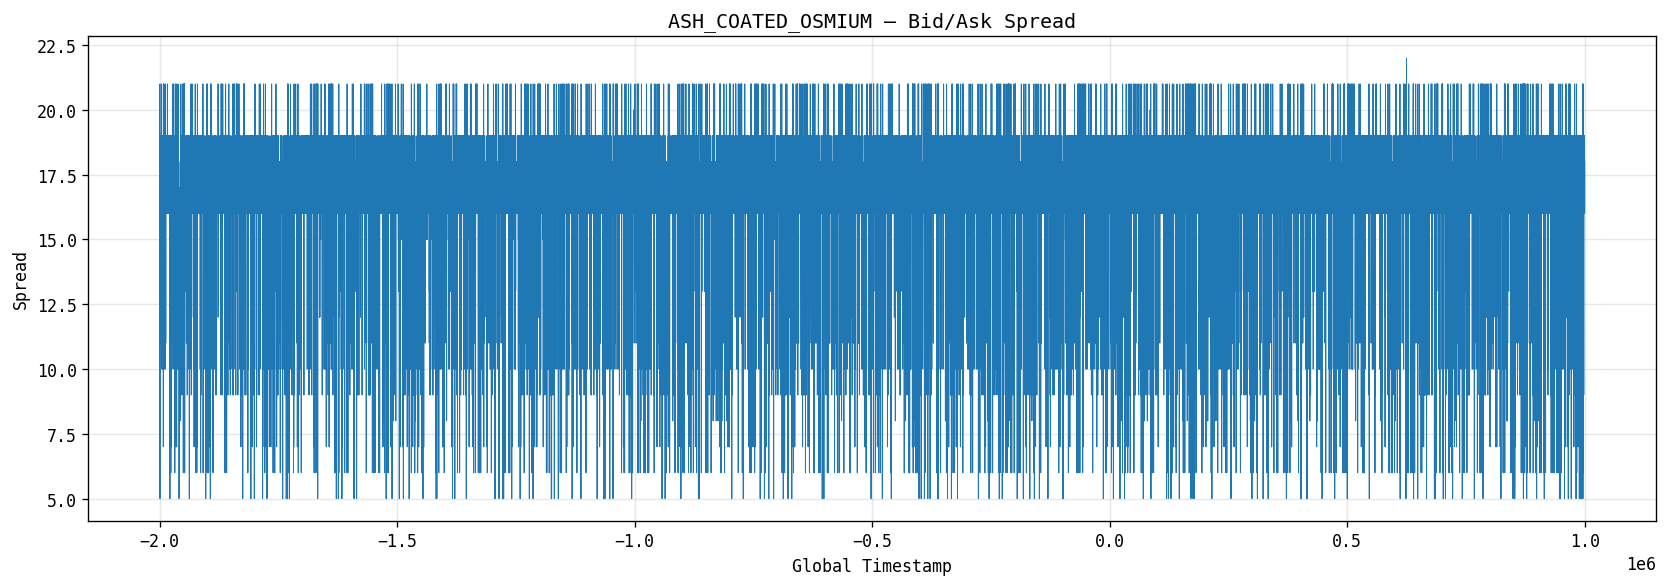

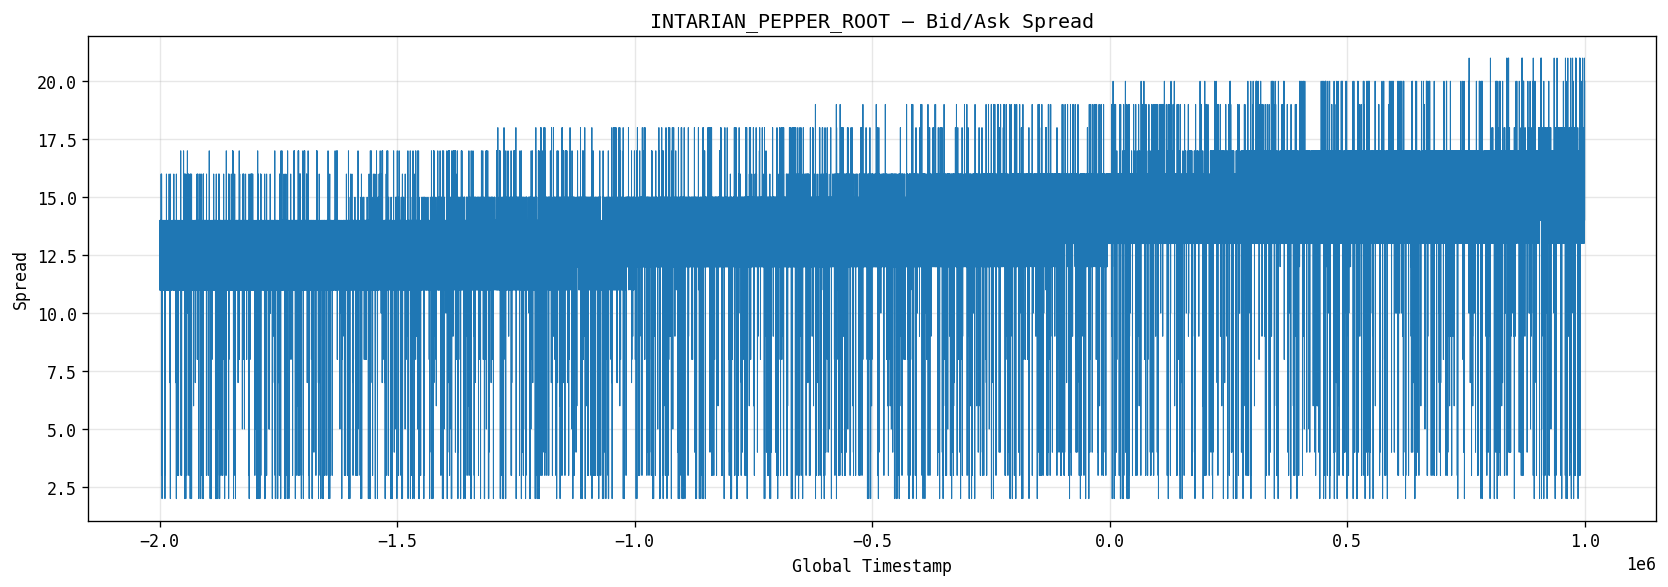

In [5]:
if prices:
    for product in products:
        xs, spreads = [], []
        for r in prices:
            if r["product"] != product:
                continue
            try:
                bid = float(r["bid_price_1"]); ask = float(r["ask_price_1"])
            except (ValueError, TypeError):
                continue
            xs.append(r["_global_ts"])
            spreads.append(ask - bid)
        if not xs:
            continue
        fig, ax = plt.subplots()
        ax.plot(xs, spreads, linewidth=0.6)
        ax.set_title(f"{product} — Bid/Ask Spread")
        ax.set_xlabel("Global Timestamp")
        ax.set_ylabel("Spread")
        plt.tight_layout()
        plt.show()

## 4. Load Trades

In [6]:
def load_trades(dataset_dir, days):
    rows = []
    for d in days:
        path = Path(dataset_dir) / f"trades_round_1_day_{d}.csv"
        if not path.exists():
            print(f"Missing: {path}")
            continue
        with open(path) as f:
            # auto-detect delimiter
            sample = f.read(2048); f.seek(0)
            delim = ";" if sample.count(";") > sample.count(",") else ","
            for r in csv.DictReader(f, delimiter=delim):
                r["_day"] = d
                r["_global_ts"] = d * 1_000_000 + int(r["timestamp"])
                rows.append(r)
    return rows

trades = load_trades(DATASET_DIR, DAYS)
print(f"Loaded {len(trades)} trades")
if trades:
    print(f"Columns: {list(trades[0].keys())}")

Loaded 2276 trades
Columns: ['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', '_day', '_global_ts']


## 5. Trade Volume Per Product

In [7]:
if trades:
    sym_key = "symbol" if "symbol" in trades[0] else "product"
    vol_by_product = defaultdict(int)
    for t in trades:
        try:
            vol_by_product[t[sym_key]] += abs(int(t.get("quantity", 0)))
        except (ValueError, TypeError):
            pass
    for p, v in sorted(vol_by_product.items(), key=lambda x: -x[1]):
        print(f"{p:30s} {v:,}")

ASH_COATED_OSMIUM              6,593
INTARIAN_PEPPER_ROOT           5,230
